# Explainable, uncertainty-aware skin lesion pre-screening: training notebook

**Decision-support prototype only. Not a diagnosis. Consult a qualified clinician.**

Sections: (1) setup and data, (2) data visualisation and engineering, (3) model architecture,
(4) training, (5) performance metrics, (6) uncertainty (MC Dropout) and review thresholds,
(7) Grad-CAM, (8) export for the API.

**Honest scope.** HAM10000 has no skin-tone labels and comes mostly from lighter-skinned patients.
Nothing in this notebook measures performance on Black / dark skin (Fitzpatrick V-VI). That is future work.
Every number reported below is produced by running this notebook; none are typed in by hand.

Runtime: *Runtime > Change runtime type > GPU (T4)*.

## 1. Setup and data

In [1]:
!pip -q install grad-cam
import os, json, random, time, zipfile, glob
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support, classification_report,
                             confusion_matrix, roc_auc_score)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# Persist everything to Google Drive so a disconnect / runtime reset never loses progress.
from google.colab import drive
drive.mount("/content/drive")
OUT = "/content/drive/MyDrive/skin_capstone/outputs"; os.makedirs(OUT, exist_ok=True)
print("checkpoints and outputs saved in:", OUT)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 3.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
device: cuda
Mounted at /content/drive
checkpoints and outputs saved in: /content/drive/MyDrive/skin_capstone/outputs


**If Colab disconnects:** reopen the notebook, *Runtime > Run all* (or run cells top to bottom again).
Setup and data cells are quick to re-run (you will need to upload `kaggle.json` again). Training resumes from the last
finished epoch of the current model, and a model that already finished training is loaded from Drive and skipped.

### Download HAM10000 from Kaggle
Run the next cell, then choose your `kaggle.json` when prompted. It is stored only in this Colab session.
**Never commit `kaggle.json` to Git.**

In [2]:
from google.colab import files
if not os.path.exists("/root/.kaggle/kaggle.json"):
    up = files.upload()  # select kaggle.json
    os.makedirs("/root/.kaggle", exist_ok=True)
    with open("/root/.kaggle/kaggle.json", "wb") as f:
        f.write(up["kaggle.json"])
    os.chmod("/root/.kaggle/kaggle.json", 0o600)

!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000 -p /content/ham --unzip -q
print(os.listdir("/content/ham"))

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
['HAM10000_metadata.csv', 'hmnist_8_8_RGB.csv', 'ham10000_images_part_2', 'hmnist_28_28_RGB.csv', 'hmnist_8_8_L.csv', 'ham10000_images_part_1', 'HAM10000_images_part_1', 'hmnist_28_28_L.csv', 'HAM10000_images_part_2']


In [3]:
meta = pd.read_csv("/content/ham/HAM10000_metadata.csv")
img_index = {os.path.splitext(os.path.basename(p))[0]: p
             for p in glob.glob("/content/ham/**/*.jpg", recursive=True)}
meta["path"] = meta["image_id"].map(img_index)
assert meta["path"].notna().all(), "some images are missing"

CLASS_CODES = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]   # alphabetical, fixed order
CLASS_NAMES = ["Actinic keratoses / intraepithelial carcinoma", "Basal cell carcinoma",
               "Benign keratosis-like lesions", "Dermatofibroma", "Melanoma",
               "Melanocytic nevi", "Vascular lesions"]
MEL_IDX = CLASS_CODES.index("mel")
meta["label"] = meta["dx"].map({c: i for i, c in enumerate(CLASS_CODES)})
print(meta.shape); meta.head()

(10015, 9)


,lesion_id,image_id,dx,dx_type,age,sex,localization,path,label
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,/content/ham/HAM10000_images_part_1/ISIC_00274...,2
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,/content/ham/HAM10000_images_part_1/ISIC_00250...,2
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/content/ham/HAM10000_images_part_1/ISIC_00267...,2
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,/content/ham/HAM10000_images_part_1/ISIC_00256...,2
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,/content/ham/HAM10000_images_part_2/ISIC_00316...,2


## 2. Data visualisation and data engineering
Questions we answer visually: how imbalanced are the classes, who is in the data (age, sex, body site),
and is there duplicate-lesion leakage risk?

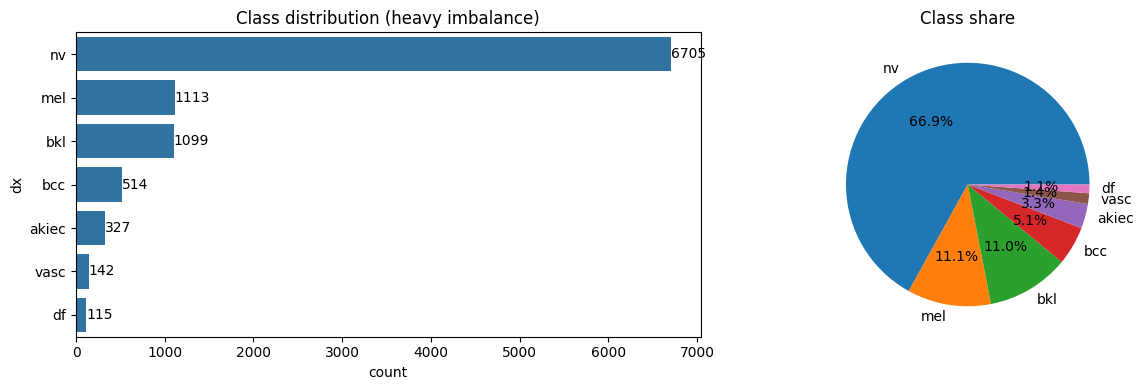

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
order = meta["dx"].value_counts().index
sns.countplot(data=meta, y="dx", order=order, ax=ax[0]); ax[0].set_title("Class distribution (heavy imbalance)")
for p in ax[0].patches: ax[0].annotate(int(p.get_width()), (p.get_width(), p.get_y()+p.get_height()/2), va="center")
meta["dx"].value_counts().plot.pie(autopct="%1.1f%%", ax=ax[1]); ax[1].set_ylabel(""); ax[1].set_title("Class share")
plt.tight_layout(); plt.savefig(f"{OUT}/fig_class_distribution.png", dpi=150); plt.show()

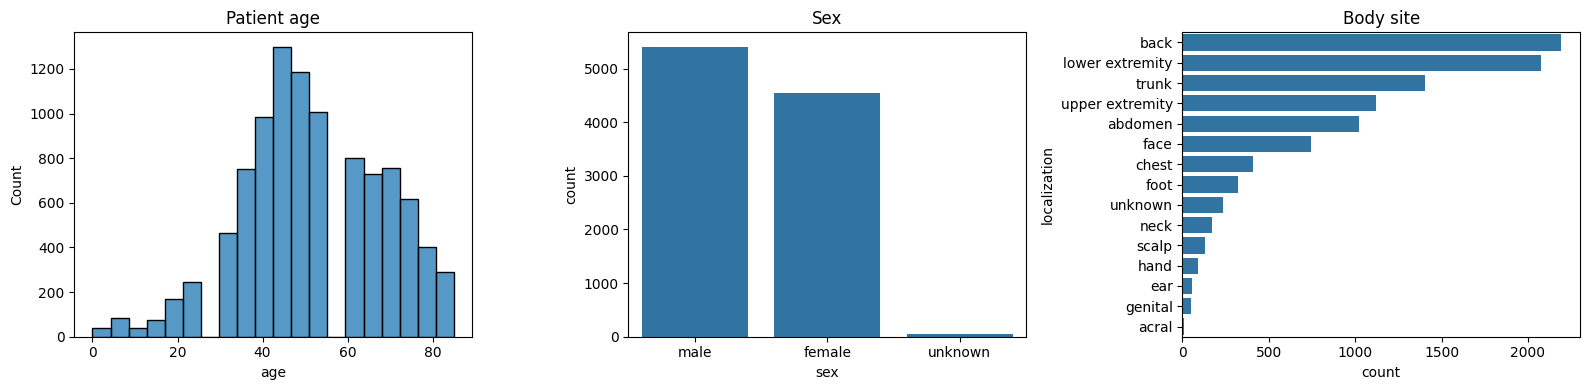

Missing values:
 age             57
sex              0
localization     0
dtype: int64

Diagnosis confirmation type:
 dx_type
histo        5340
follow_up    3704
consensus     902
confocal       69
Name: count, dtype: int64


In [5]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(meta["age"].dropna(), bins=20, ax=ax[0]); ax[0].set_title("Patient age")
sns.countplot(data=meta, x="sex", ax=ax[1]); ax[1].set_title("Sex")
sns.countplot(data=meta, y="localization", order=meta["localization"].value_counts().index, ax=ax[2]); ax[2].set_title("Body site")
plt.tight_layout(); plt.savefig(f"{OUT}/fig_demographics.png", dpi=150); plt.show()

print("Missing values:\n", meta[["age", "sex", "localization"]].isna().sum())
print("\nDiagnosis confirmation type:\n", meta["dx_type"].value_counts())

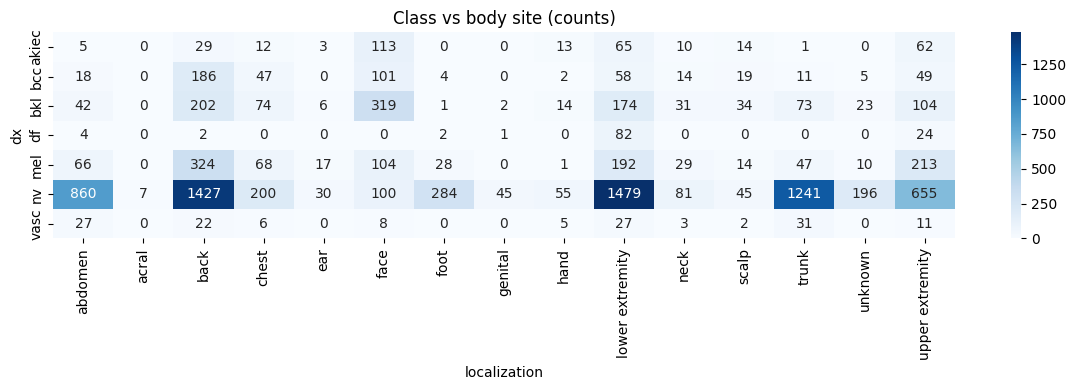

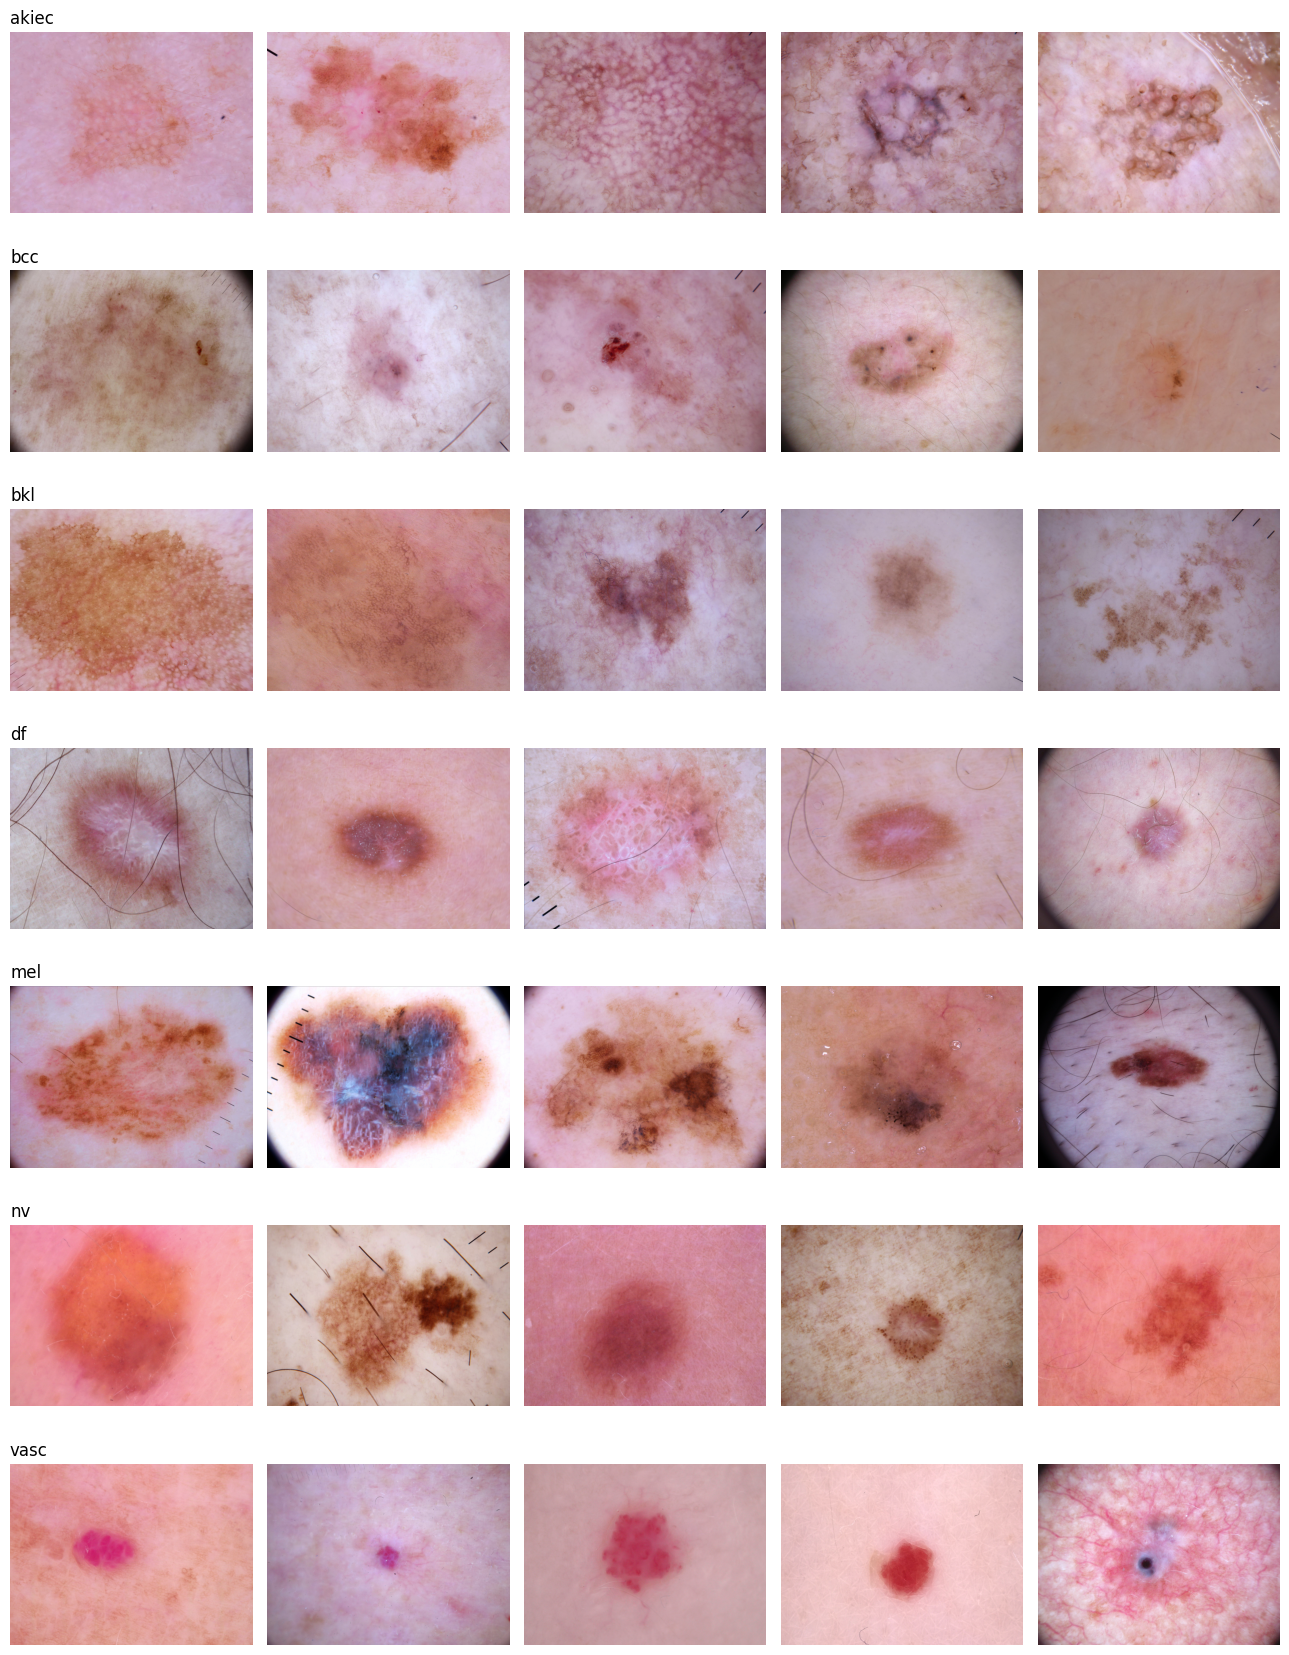

In [6]:
ct = pd.crosstab(meta["dx"], meta["localization"])
plt.figure(figsize=(12, 4)); sns.heatmap(ct, annot=True, fmt="d", cmap="Blues")
plt.title("Class vs body site (counts)"); plt.tight_layout(); plt.savefig(f"{OUT}/fig_class_site.png", dpi=150); plt.show()

fig, axs = plt.subplots(len(CLASS_CODES), 5, figsize=(13, 17))
for r, c in enumerate(CLASS_CODES):
    sample = meta[meta.dx == c].sample(5, random_state=SEED)
    for k, (_, row) in enumerate(sample.iterrows()):
        axs[r, k].imshow(Image.open(row["path"])); axs[r, k].axis("off")
    axs[r, 0].set_title(c, loc="left")
plt.tight_layout(); plt.savefig(f"{OUT}/fig_samples.png", dpi=120); plt.show()

### Data engineering decision: split by *lesion*, not by image
HAM10000 contains several photos of the same lesion (`lesion_id`). A random image-level split would put near-identical
photos in train and test and inflate the scores. We split with `StratifiedGroupKFold` grouped by `lesion_id`
(about 70/15/15), stratified by class.

In [7]:
print("images:", len(meta), "| unique lesions:", meta["lesion_id"].nunique())

sgkf = StratifiedGroupKFold(n_splits=7, shuffle=True, random_state=SEED)   # 7 folds ~ 14.3% each
folds = list(sgkf.split(meta, meta["label"], groups=meta["lesion_id"]))
test_idx, val_idx = folds[0][1], folds[1][1]
train_idx = np.concatenate([folds[i][1] for i in range(2, 7)])
train_df, val_df, test_df = meta.iloc[train_idx], meta.iloc[val_idx], meta.iloc[test_idx]

assert not set(train_df.lesion_id) & set(val_df.lesion_id)
assert not set(train_df.lesion_id) & set(test_df.lesion_id)
assert not set(val_df.lesion_id) & set(test_df.lesion_id)
split_tbl = pd.DataFrame({n: d["dx"].value_counts() for n, d in
                          [("train", train_df), ("val", val_df), ("test", test_df)]})
split_tbl.to_csv(f"{OUT}/split_class_counts.csv"); print(split_tbl)

images: 10015 | unique lesions: 7470
       train  val  test
dx                     
akiec    230   63    34
bcc      358   67    89
bkl      772  159   168
df        89   17     9
mel      782  185   146
nv      4796  935   974
vasc      89   32    21


In [8]:
# Class imbalance handling: class-weighted loss (inverse frequency, normalised).
counts = train_df["label"].value_counts().sort_index().values
class_w = torch.tensor(counts.sum() / (len(counts) * counts), dtype=torch.float32)
print(dict(zip(CLASS_CODES, class_w.numpy().round(2))))

INPUT = 300
MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]   # ImageNet
# Resize directly to 300x300 (no crop) so inference matches the API exactly.
train_tf = transforms.Compose([
    transforms.Resize((INPUT, INPUT)),
    transforms.RandomHorizontalFlip(), transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.02),
    transforms.ToTensor(), transforms.Normalize(MEAN, STD)])
eval_tf = transforms.Compose([transforms.Resize((INPUT, INPUT)), transforms.ToTensor(), transforms.Normalize(MEAN, STD)])

class HAM(Dataset):
    def __init__(self, df, tf): self.paths, self.labels, self.tf = df["path"].values, df["label"].values, tf
    def __len__(self): return len(self.paths)
    def __getitem__(self, i): return self.tf(Image.open(self.paths[i]).convert("RGB")), int(self.labels[i])

BS = 32
train_dl = DataLoader(HAM(train_df, train_tf), BS, shuffle=True, num_workers=2, pin_memory=True)
val_dl = DataLoader(HAM(val_df, eval_tf), BS, num_workers=2)
test_dl = DataLoader(HAM(test_df, eval_tf), BS, num_workers=2)

{'akiec': np.float32(4.42), 'bcc': np.float32(2.84), 'bkl': np.float32(1.32), 'df': np.float32(11.42), 'mel': np.float32(1.3), 'nv': np.float32(0.21), 'vasc': np.float32(11.42)}


## 3. Model architecture
**Proposed: EfficientNet-B3** (ImageNet pre-trained, fine-tuned end to end).
Stem conv -> 26 MBConv blocks (depthwise-separable convs, squeeze-and-excitation, **SiLU/Swish** activations, batch norm)
-> 1x1 conv head -> global average pooling -> `Dropout(0.3)` -> `Linear(1536, 7)`.
**Baseline: MobileNetV2** (inverted residuals, ReLU6, `Dropout(0.2)` -> `Linear(1280, 7)`).

**Optimisation:** AdamW (lr 3e-4, weight decay 1e-4), cosine-annealing schedule, class-weighted cross-entropy,
early stopping on validation macro-F1, gradient clipping, mixed precision (AMP).

In [9]:
def build_effnet_b3(pretrained=True):
    m = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.DEFAULT if pretrained else None)
    m.classifier[1] = nn.Linear(m.classifier[1].in_features, len(CLASS_CODES))
    return m

def build_mobilenet_v2(pretrained=True):
    m = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT if pretrained else None)
    m.classifier[1] = nn.Linear(m.classifier[1].in_features, len(CLASS_CODES))
    return m

eff = build_effnet_b3()
print(eff.classifier)
n_params = lambda m: sum(p.numel() for p in m.parameters())
print(f"EfficientNet-B3 params: {n_params(eff)/1e6:.2f}M | MobileNetV2 params: {n_params(build_mobilenet_v2())/1e6:.2f}M")
!pip -q install torchinfo
from torchinfo import summary
summary(eff, input_size=(1, 3, INPUT, INPUT), depth=2, col_names=("output_size", "num_params"))

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 197MB/s]


Sequential(
  (0): Dropout(p=0.3, inplace=True)
  (1): Linear(in_features=1536, out_features=7, bias=True)
)
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 149MB/s]


EfficientNet-B3 params: 10.71M | MobileNetV2 params: 2.23M


Layer (type:depth-idx)                                  Output Shape              Param #
EfficientNet                                            [1, 7]                    --
├─Sequential: 1-1                                       [1, 1536, 10, 10]         --
│    └─Conv2dNormActivation: 2-1                        [1, 40, 150, 150]         1,160
│    └─Sequential: 2-2                                  [1, 24, 150, 150]         3,504
│    └─Sequential: 2-3                                  [1, 32, 75, 75]           48,118
│    └─Sequential: 2-4                                  [1, 48, 38, 38]           110,912
│    └─Sequential: 2-5                                  [1, 96, 19, 19]           638,700
│    └─Sequential: 2-6                                  [1, 136, 19, 19]          1,387,760
│    └─Sequential: 2-7                                  [1, 232, 10, 10]          4,628,964
│    └─Sequential: 2-8                                  [1, 384, 10, 10]          3,284,218
│    └─Conv2dNormAc

## 4. Training

In [10]:
def predict_probs(model, dl):
    model.eval(); P, Y = [], []
    with torch.no_grad(), torch.autocast(device_type=device.type, enabled=device.type == "cuda"):
        for x, y in dl:
            P.append(F.softmax(model(x.to(device)).float(), 1).cpu()); Y.append(y)
    return torch.cat(P).numpy(), torch.cat(Y).numpy()

def macro_f1(y, p): return precision_recall_fscore_support(y, p, average="macro", zero_division=0)[2]

def save_atomic(obj, path):
    # write to a temp file then rename, so a disconnect mid-write cannot corrupt the checkpoint
    torch.save(obj, path + ".tmp"); os.replace(path + ".tmp", path)

def train_model(model, name, epochs, patience=4, lr=3e-4):
    model.to(device)
    crit = nn.CrossEntropyLoss(weight=class_w.to(device))
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    scaler = torch.cuda.amp.GradScaler(enabled=device.type == "cuda")
    ck_path = f"{OUT}/{name}_checkpoint.pt"
    best, bad, hist, start_ep, done = -1, 0, [], 0, False

    if os.path.exists(ck_path):                       # ---- resume ----
        ck = torch.load(ck_path, map_location=device)
        model.load_state_dict(ck["model"]); opt.load_state_dict(ck["opt"])
        sched.load_state_dict(ck["sched"]); scaler.load_state_dict(ck["scaler"])
        best, bad, hist, start_ep, done = ck["best"], ck["bad"], ck["hist"], ck["epoch"], ck["done"]
        print(f"[{name}] resumed from checkpoint: {start_ep} epochs already done, best val macroF1 {best:.4f}"
              + (" (training already finished)" if done else ""))

    def checkpoint(epoch, finished):
        save_atomic(dict(model=model.state_dict(), opt=opt.state_dict(), sched=sched.state_dict(),
                         scaler=scaler.state_dict(), best=best, bad=bad, hist=hist, epoch=epoch, done=finished), ck_path)

    for ep in range(start_ep, 0 if done else epochs):
        model.train(); t0, tot = time.time(), 0
        for x, y in train_dl:
            x, y = x.to(device), y.to(device)
            opt.zero_grad(set_to_none=True)
            with torch.autocast(device_type=device.type, enabled=device.type == "cuda"):
                loss = crit(model(x), y)
            scaler.scale(loss).backward()
            scaler.unscale_(opt); nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt); scaler.update(); tot += loss.item() * len(y)
        sched.step()
        P, Y = predict_probs(model, val_dl)
        f1, acc = macro_f1(Y, P.argmax(1)), accuracy_score(Y, P.argmax(1))
        hist.append(dict(epoch=ep+1, train_loss=tot/len(train_df), val_macro_f1=f1, val_acc=acc))
        print(f"[{name}] ep {ep+1}/{epochs} loss {tot/len(train_df):.4f} val acc {acc:.4f} val macroF1 {f1:.4f} ({time.time()-t0:.0f}s)")
        if f1 > best:
            best, bad = f1, 0; save_atomic(model.state_dict(), f"{OUT}/{name}_best.pth")
        else:
            bad += 1
        stop = bad >= patience
        checkpoint(ep + 1, finished=stop or ep + 1 == epochs)   # saved to Drive after EVERY epoch
        if stop: print("early stop"); break
    if not done: checkpoint(len(hist), finished=True)
    model.load_state_dict(torch.load(f"{OUT}/{name}_best.pth", map_location=device))
    h = pd.DataFrame(hist); h.to_csv(f"{OUT}/{name}_history.csv", index=False)
    return model, h

# Train one model per cell so a disconnect only ever costs the current epoch.

eff, h_eff = train_model(eff, "efficientnet_b3", epochs=15)

/tmp/ipykernel_5837/2404710829.py:19: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=device.type == "cuda")


[efficientnet_b3] ep 1/15 loss 1.1630 val acc 0.6968 val macroF1 0.5640 (192s)
[efficientnet_b3] ep 2/15 loss 0.7025 val acc 0.7764 val macroF1 0.6454 (161s)
[efficientnet_b3] ep 3/15 loss 0.5503 val acc 0.8182 val macroF1 0.7108 (160s)
[efficientnet_b3] ep 4/15 loss 0.4191 val acc 0.8086 val macroF1 0.6939 (160s)
[efficientnet_b3] ep 5/15 loss 0.3363 val acc 0.8416 val macroF1 0.7221 (162s)
[efficientnet_b3] ep 6/15 loss 0.2755 val acc 0.8374 val macroF1 0.7107 (162s)
[efficientnet_b3] ep 7/15 loss 0.2166 val acc 0.8326 val macroF1 0.7237 (158s)
[efficientnet_b3] ep 8/15 loss 0.1730 val acc 0.8272 val macroF1 0.7112 (160s)
[efficientnet_b3] ep 9/15 loss 0.1391 val acc 0.8464 val macroF1 0.7212 (158s)
[efficientnet_b3] ep 10/15 loss 0.1144 val acc 0.8553 val macroF1 0.7445 (165s)
[efficientnet_b3] ep 11/15 loss 0.0741 val acc 0.8567 val macroF1 0.7442 (163s)
[efficientnet_b3] ep 12/15 loss 0.0653 val acc 0.8464 val macroF1 0.7271 (169s)
[efficientnet_b3] ep 13/15 loss 0.0536 val acc 0.

In [11]:
mob, h_mob = train_model(build_mobilenet_v2(), "mobilenet_v2", epochs=15)

/tmp/ipykernel_5837/2404710829.py:19: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=device.type == "cuda")


[mobilenet_v2] ep 1/15 loss 1.2738 val acc 0.6646 val macroF1 0.5292 (163s)
[mobilenet_v2] ep 2/15 loss 0.8535 val acc 0.7551 val macroF1 0.6211 (140s)
[mobilenet_v2] ep 3/15 loss 0.6838 val acc 0.7908 val macroF1 0.6745 (141s)
[mobilenet_v2] ep 4/15 loss 0.5780 val acc 0.8354 val macroF1 0.6989 (141s)
[mobilenet_v2] ep 5/15 loss 0.5258 val acc 0.7826 val macroF1 0.6369 (146s)
[mobilenet_v2] ep 6/15 loss 0.4119 val acc 0.8258 val macroF1 0.7010 (142s)
[mobilenet_v2] ep 7/15 loss 0.3739 val acc 0.8045 val macroF1 0.6693 (139s)
[mobilenet_v2] ep 8/15 loss 0.3299 val acc 0.8299 val macroF1 0.6947 (141s)
[mobilenet_v2] ep 9/15 loss 0.2896 val acc 0.8368 val macroF1 0.6987 (139s)
[mobilenet_v2] ep 10/15 loss 0.2543 val acc 0.8278 val macroF1 0.6918 (138s)
early stop


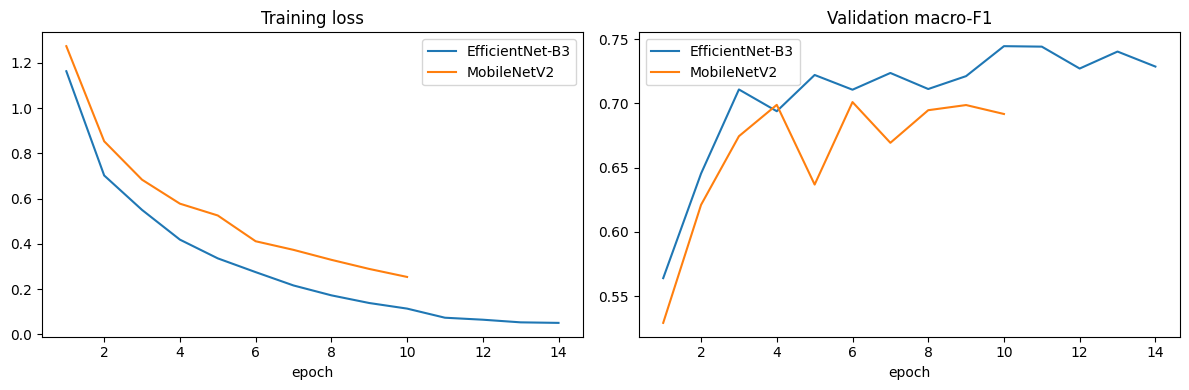

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for h, n in [(h_eff, "EfficientNet-B3"), (h_mob, "MobileNetV2")]:
    ax[0].plot(h.epoch, h.train_loss, label=n); ax[1].plot(h.epoch, h.val_macro_f1, label=n)
ax[0].set_title("Training loss"); ax[1].set_title("Validation macro-F1"); ax[0].legend(); ax[1].legend()
for a in ax: a.set_xlabel("epoch")
plt.tight_layout(); plt.savefig(f"{OUT}/fig_training_curves.png", dpi=150); plt.show()

## 5. Initial performance metrics (held-out test set)
Accuracy alone is misleading on imbalanced data (predicting "nv" always gives ~67%), so we report macro-averaged
precision / recall / F1, per-class results, and melanoma sensitivity.

In [13]:
def evaluate(model, name):
    P, Y = predict_probs(model, test_dl); pred = P.argmax(1)
    pr, rc, f1, _ = precision_recall_fscore_support(Y, pred, average="macro", zero_division=0)
    try: auc = roc_auc_score(Y, P, multi_class="ovr", average="macro")
    except ValueError: auc = float("nan")
    mel_sens = ((pred == MEL_IDX) & (Y == MEL_IDX)).sum() / max((Y == MEL_IDX).sum(), 1)
    return dict(model=name, accuracy=accuracy_score(Y, pred), macro_precision=pr, macro_recall=rc,
                macro_f1=f1, macro_auc_ovr=auc, melanoma_sensitivity=mel_sens), P, Y

res_eff, P_eff, Y_test = evaluate(eff, "EfficientNet-B3")
res_mob, P_mob, _ = evaluate(mob, "MobileNetV2 (baseline)")
cmp_df = pd.DataFrame([res_eff, res_mob]).round(4)
cmp_df.to_csv(f"{OUT}/test_metrics_comparison.csv", index=False); cmp_df

,model,accuracy,macro_precision,macro_recall,macro_f1,macro_auc_ovr,melanoma_sensitivity
0,EfficientNet-B3,0.8348,0.7310,0.7431,0.7322,0.9632,0.5753
1,MobileNetV2 (baseline),0.8099,0.6495,0.7224,0.6727,0.9539,0.4178


              precision    recall  f1-score   support

       akiec      0.450     0.529     0.486        34
         bcc      0.729     0.876     0.796        89
         bkl      0.772     0.565     0.653       168
          df      0.875     0.778     0.824         9
         mel      0.491     0.575     0.530       146
          nv      0.930     0.925     0.927       974
        vasc      0.870     0.952     0.909        21

    accuracy                          0.835      1441
   macro avg      0.731     0.743     0.732      1441
weighted avg      0.842     0.835     0.836      1441



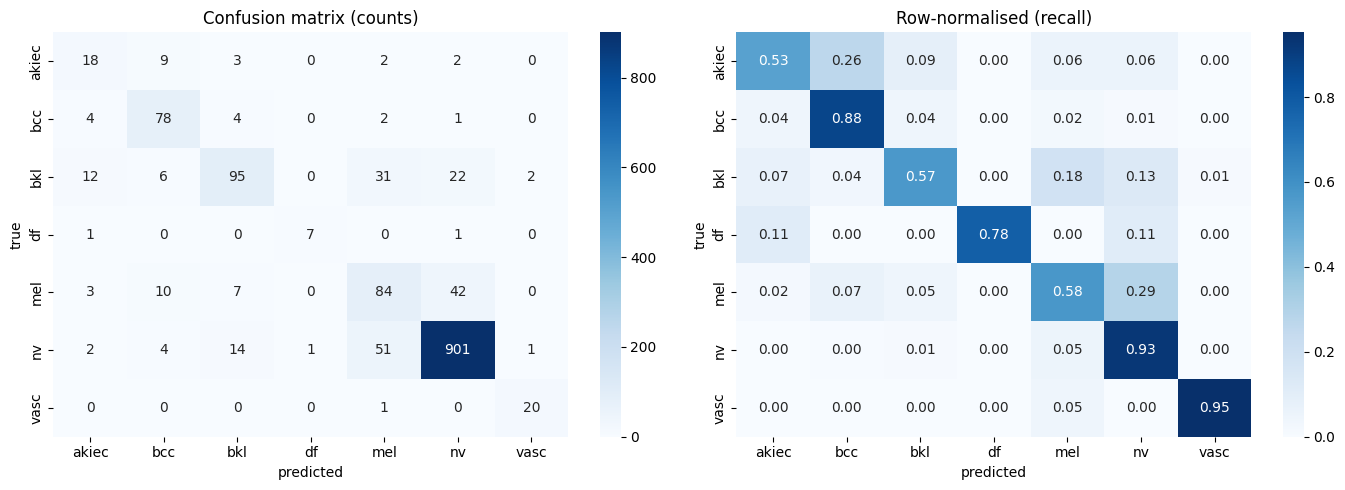

In [14]:
print(classification_report(Y_test, P_eff.argmax(1), target_names=CLASS_CODES, digits=3, zero_division=0))
pd.DataFrame(classification_report(Y_test, P_eff.argmax(1), target_names=CLASS_CODES, output_dict=True, zero_division=0)
             ).T.round(4).to_csv(f"{OUT}/per_class_report_efficientnet_b3.csv")

cm = confusion_matrix(Y_test, P_eff.argmax(1))
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_CODES, yticklabels=CLASS_CODES, ax=ax[0]); ax[0].set_title("Confusion matrix (counts)")
sns.heatmap(cm / cm.sum(1, keepdims=True), annot=True, fmt=".2f", cmap="Blues", xticklabels=CLASS_CODES, yticklabels=CLASS_CODES, ax=ax[1]); ax[1].set_title("Row-normalised (recall)")
for a in ax: a.set_xlabel("predicted"); a.set_ylabel("true")
plt.tight_layout(); plt.savefig(f"{OUT}/fig_confusion_matrix.png", dpi=150); plt.show()

## 6. Uncertainty with MC Dropout and review thresholds
Following the API contract: run the backbone **once**, then run `classifier` **T=10** times with dropout active and
average the softmax. Entropy `-sum(p log p)` measures how unsure the model is.
**Review flag = entropy >= entropy_threshold OR P(melanoma) >= melanoma_flag_threshold.**
Both thresholds are chosen on the **validation** set (never the test set), then evaluated once on test.

In [15]:
T_PASSES = 10
def mc_predict(model, dl, T=T_PASSES):
    model.eval(); P, Y = [], []
    with torch.no_grad():
        for x, y in dl:
            feats = F.adaptive_avg_pool2d(model.features(x.to(device)), 1).flatten(1)
            model.classifier.train()   # dropout on
            p = torch.stack([F.softmax(model.classifier(feats), 1) for _ in range(T)]).mean(0)
            model.classifier.eval()
            P.append(p.cpu()); Y.append(y)
    return torch.cat(P).numpy(), torch.cat(Y).numpy()

entropy = lambda P: -(P * np.log(P + 1e-12)).sum(1)
Pv, Yv = mc_predict(eff, val_dl); Pt, Yt = mc_predict(eff, test_dl)
Hv, Ht = entropy(Pv), entropy(Pt)

# Entropy threshold: 80th percentile of validation entropy (flags roughly the most uncertain 20%).
ENT_THR = float(np.percentile(Hv, 80))
# Melanoma threshold: highest value that still reaches >=90% melanoma recall on validation.
mel_true = Yv == MEL_IDX
cands = np.linspace(0.05, 0.95, 91)
ok = [t for t in cands if (Pv[mel_true, MEL_IDX] >= t).mean() >= 0.90]
MEL_THR = float(max(ok)) if ok else 0.05
print(f"entropy_threshold={ENT_THR:.4f}  melanoma_flag_threshold={MEL_THR:.2f}  (max entropy ln7={np.log(7):.3f})")

entropy_threshold=0.4129  melanoma_flag_threshold=0.05  (max entropy ln7=1.946)


{
  "mc_accuracy": 0.835530881332408,
  "review_rate": 0.31297709923664124,
  "accuracy_unflagged": 0.9353535353535354,
  "accuracy_flagged": 0.6164079822616408,
  "errors_caught_by_flag": 0.729957805907173,
  "melanoma_sensitivity_argmax": 0.6095890410958904,
  "melanoma_sensitivity_with_flag": 0.8767123287671232
}


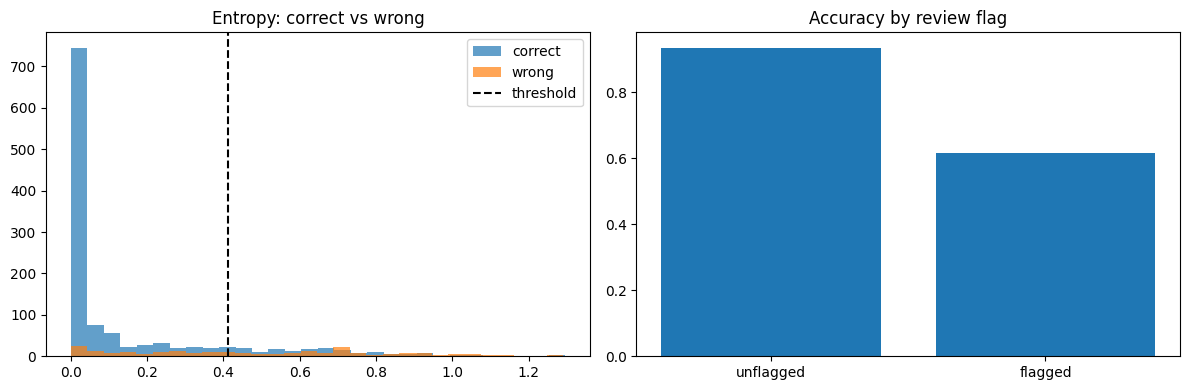

In [16]:
flag_t = (Ht >= ENT_THR) | (Pt[:, MEL_IDX] >= MEL_THR)
pred_t = Pt.argmax(1); correct = pred_t == Yt
mel_t = Yt == MEL_IDX
mission = dict(
    mc_accuracy=float(correct.mean()),
    review_rate=float(flag_t.mean()),
    accuracy_unflagged=float(correct[~flag_t].mean()) if (~flag_t).any() else None,
    accuracy_flagged=float(correct[flag_t].mean()) if flag_t.any() else None,
    errors_caught_by_flag=float(flag_t[~correct].mean()) if (~correct).any() else None,
    melanoma_sensitivity_argmax=float(correct[mel_t].mean()),
    melanoma_sensitivity_with_flag=float((correct | flag_t)[mel_t].mean()),
)
print(json.dumps(mission, indent=2))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(Ht[correct], bins=30, alpha=.7, label="correct"); ax[0].hist(Ht[~correct], bins=30, alpha=.7, label="wrong")
ax[0].axvline(ENT_THR, color="k", ls="--", label="threshold"); ax[0].set_title("Entropy: correct vs wrong"); ax[0].legend()
ax[1].bar(["unflagged", "flagged"], [mission["accuracy_unflagged"] or 0, mission["accuracy_flagged"] or 0]); ax[1].set_title("Accuracy by review flag")
plt.tight_layout(); plt.savefig(f"{OUT}/fig_uncertainty.png", dpi=150); plt.show()

## 7. Grad-CAM explainability
Target layer `model.features[-1]`, target = top predicted class, eval mode, fp32. Heatmaps show *where the model looked*;
they are not proof that the model is clinically reasoning correctly.

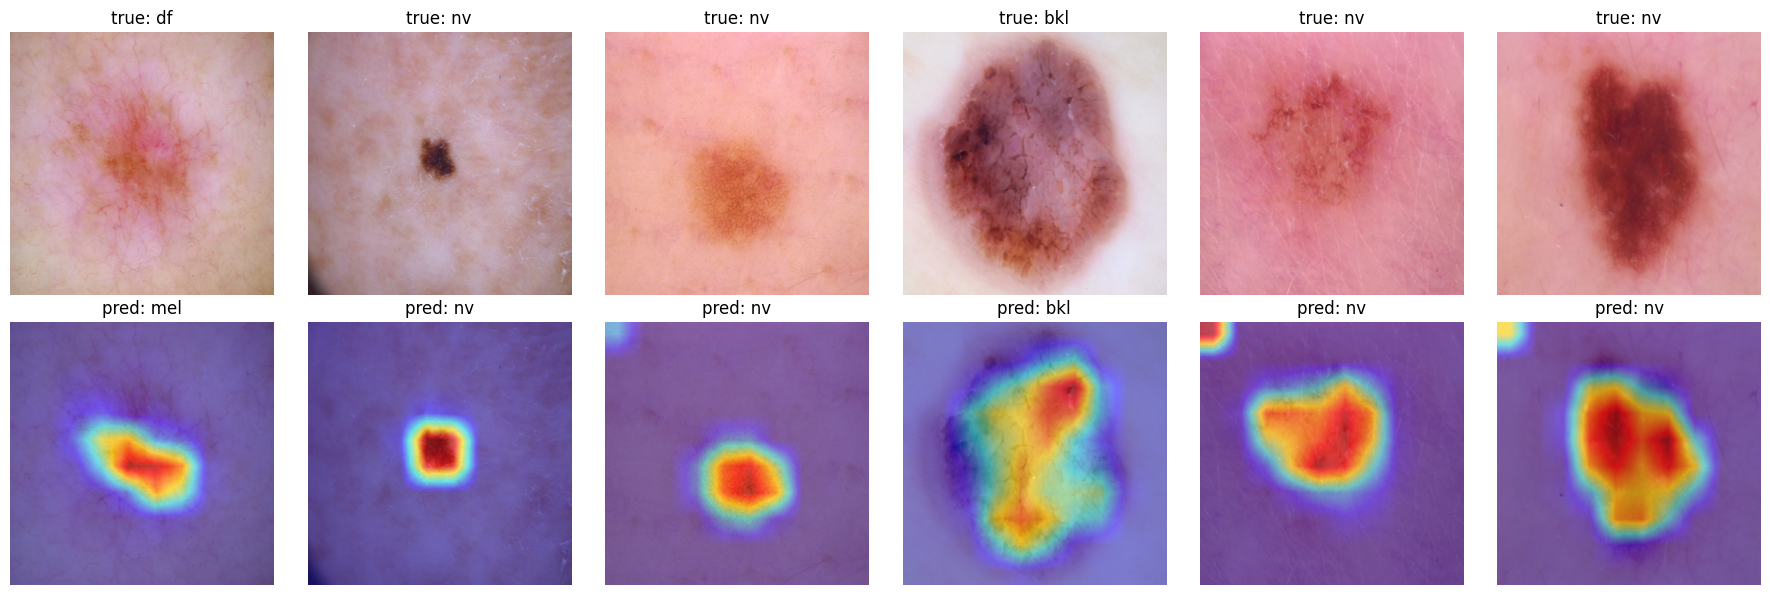

In [17]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

eff.eval().float()
cam = GradCAM(model=eff, target_layers=[eff.features[-1]])
samples = test_df.sample(6, random_state=SEED)
fig, axs = plt.subplots(2, 6, figsize=(18, 6))
for k, (_, row) in enumerate(samples.iterrows()):
    img = Image.open(row["path"]).convert("RGB").resize((INPUT, INPUT))
    x = eval_tf(img.copy()).unsqueeze(0).to(device)
    with torch.no_grad(): top = int(F.softmax(eff(x), 1).argmax())
    g = cam(input_tensor=x, targets=[ClassifierOutputTarget(top)])[0]
    axs[0, k].imshow(img); axs[0, k].set_title(f"true: {row['dx']}"); axs[0, k].axis("off")
    axs[1, k].imshow(show_cam_on_image(np.asarray(img, dtype=np.float32) / 255, g, use_rgb=True))
    axs[1, k].set_title(f"pred: {CLASS_CODES[top]}"); axs[1, k].axis("off")
plt.tight_layout(); plt.savefig(f"{OUT}/fig_gradcam_examples.png", dpi=130); plt.show()

## 8. Export for the API

In [18]:
cfg = dict(
    model_name="efficientnet_b3", input_size=INPUT, mean=MEAN, std=STD,
    class_codes=CLASS_CODES, class_names=CLASS_NAMES,
    mc_dropout_passes=T_PASSES, entropy_threshold=ENT_THR,
    melanoma_flag_threshold=MEL_THR, melanoma_index=MEL_IDX,
    test_metrics={k: float(v) for k, v in res_eff.items() if k != "model"},
    mission_metrics=mission,
    disclaimer="Decision-support prototype only. Not a diagnosis. Consult a qualified clinician.",
    limitations="Trained on HAM10000 (no skin-tone labels, mostly lighter skin). Not validated on Fitzpatrick V-VI.",
)
with open(f"{OUT}/model_config.json", "w") as f: json.dump(cfg, f, indent=2)
print(json.dumps(cfg, indent=2)[:1500])

!cd {OUT} && zip -q -r /content/skin_outputs.zip . -x "*_checkpoint.pt" "mobilenet_v2_best.pth"
files.download("/content/skin_outputs.zip")

{
  "model_name": "efficientnet_b3",
  "input_size": 300,
  "mean": [
    0.485,
    0.456,
    0.406
  ],
  "std": [
    0.229,
    0.224,
    0.225
  ],
  "class_codes": [
    "akiec",
    "bcc",
    "bkl",
    "df",
    "mel",
    "nv",
    "vasc"
  ],
  "class_names": [
    "Actinic keratoses / intraepithelial carcinoma",
    "Basal cell carcinoma",
    "Benign keratosis-like lesions",
    "Dermatofibroma",
    "Melanoma",
    "Melanocytic nevi",
    "Vascular lesions"
  ],
  "mc_dropout_passes": 10,
  "entropy_threshold": 0.4129127562046051,
  "melanoma_flag_threshold": 0.05,
  "melanoma_index": 4,
  "test_metrics": {
    "accuracy": 0.8348369188063844,
    "macro_precision": 0.7309925050234728,
    "macro_recall": 0.7431207114540728,
    "macro_f1": 0.732192342518835,
    "macro_auc_ovr": 0.963228705361824,
    "melanoma_sensitivity": 0.5753424657534246
  },
  "mission_metrics": {
    "mc_accuracy": 0.835530881332408,
    "review_rate": 0.31297709923664124,
    "accuracy_unflagge

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Next steps after this run
1. Unzip `skin_outputs.zip`; copy `efficientnet_b3_best.pth` and `model_config.json` into `backend/model/`.
2. Paste the metric tables back into the README (real numbers only).
3. Future work: evaluate on a diverse external set with Fitzpatrick labels and report sensitivity by skin tone.